# Reproduction: Benchmarking Phenotypic Clustering Algorithms via Empirically Calibrated Simulations

**Paper:** Naino Jika A. K. (2025), *Benchmarking Phenotypic Clustering Algorithms via Empirically Calibrated Simulations: A Diagnostic Framework to Improve Biodiversity Assessment in Neglected Crops*, bioRxiv 2025.07.16.665063v1, DOI [`10.1101/2025.07.16.665063`](https://doi.org/10.1101/2025.07.16.665063).

**Code:** "Simulation Benchmark Scripts for Phenotypic Clustering in Neglected Crops", Zenodo record [`15877863`](https://zenodo.org/records/15877863) (DOI 10.5281/zenodo.15877863), CC-BY-4.0, author NAINO JIKA, Abdel Kader (Université Abdou Moumouni).

**Scope of this notebook (minimal faithful reproduction):** run the paper's **realistic fonio-calibrated simulation scenario** — generate synthetic phenotypic datasets with the author's `simulate_populations.R` calibrated by `params.R` (3 populations of 91/43/46 individuals, 8 correlated and heteroscedastic traits, target phenotypic Fst ≈ 0.15, gamma-distributed grain yield), benchmark the author's **11 clustering algorithms** over the paper's **100 repetitions**, and compute ARI / NMI / Silhouette / Davies–Bouldin plus betadisper and phenotypic Fst validation statistics, exactly as encoded in the author's `clustering_benchmark.R`, `validation_tools.R` and `result_analysis.R`.

**Known deviations (documented):**
- The archive has **no `main.R`** despite the README referencing it, so the repetition loop is assembled here directly from the author's functions (seed `20250716 + rep` chosen by us; the archive specifies no seed).
- `result_analysis.R` calls `library(rstatix)`, but `rstatix` is absent from the author's `load_packages.R`; we install it in addition.

**Runtime:** CPU only — this is pure R statistical simulation; there is no GPU code path in the author's scripts. Select a **CPU runtime**. (日本語: このノートブックは純粋なRの統計シミュレーションです。GPU不要なので **CPU ランタイム** を選択してください。)

### 1. Check the R runtime

This notebook uses a Python kernel only as a **launcher**: all scientific computation runs the author's original R scripts via `Rscript`, preserving the author's calculations, parameters and outputs. (日本語: このノートブックのPythonカーネルは起動装置に過ぎません。科学計算はすべて著者のRスクリプトを `Rscript` で実行します。)

Expected result: the preinstalled R (version ≥ 4.0) is found and its version string is printed.

In [ ]:
import subprocess

def rscript(code, timeout=3600):
    r = subprocess.run(["/usr/bin/Rscript", "-e", code], capture_output=True, text=True, timeout=timeout)
    print(r.stdout)
    if r.stderr.strip():
        print("--- R stderr ---\n" + r.stderr)
    if r.returncode != 0:
        raise RuntimeError(f"Rscript failed with rc={r.returncode}")
    return r

rscript('cat(R.version.string, "\n")')

R version 4.6.1 (2026-06-24) 



CompletedProcess(args=['/usr/bin/Rscript', '-e', 'cat(R.version.string, "\n")'], returncode=0, stdout='R version 4.6.1 (2026-06-24) \n', stderr='')

### 2. Install the author's R package set (+ rstatix)

The author's `load_packages.R` requires 26 packages and **stops** if any is missing, so we install exactly that list from the Posit Public Package Manager binary repository (fast prebuilt Linux binaries for the Colab Ubuntu image), plus `rstatix` which `result_analysis.R` needs but the author's loader omits.

Expected result: all packages report `TRUE` availability (first run: about 1–3 minutes on CPU).

In [ ]:
install_code = r"""
options(repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"))
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))
pkgs <- c("tidyverse", "FactoMineR", "factoextra", "cluster", "mclust", "dbscan", "kernlab",
          "apcluster", "vegan", "aricode", "umap", "MASS", "Matrix", "future", "furrr",
          "data.table", "ggplot2", "writexl", "fpc", "clusterCrit", "meanShiftR", "kohonen",
          "tclust", "e1071", "jsonlite", "mixsmsn", "rstatix")
missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
cat("missing before install:", paste(missing, collapse = ", "), "\n")
if (length(missing)) install.packages(missing)
ok <- sapply(pkgs, requireNamespace, quietly = TRUE)
cat("STILL MISSING:", paste(names(ok)[!ok], collapse = ", "), "\n")
stopifnot(all(ok))
"""
open("/content/install_r_packages.R", "w").write(install_code)
rscript(open("/content/install_r_packages.R").read())

missing before install: FactoMineR, factoextra, mclust, dbscan, kernlab, apcluster, vegan, aricode, umap, future, furrr, writexl, fpc, clusterCrit, meanShiftR, kohonen, tclust, e1071, mixsmsn, rstatix 
STILL MISSING:  

--- R stderr ---
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘numDeriv’, ‘showtextdb’, ‘viridis’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘RcppTOML’, ‘here’, ‘png’, ‘RcppEigen’, ‘modeltools’, ‘DEoptimR’, ‘iterators’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘ggrepel’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘dendextend’, ‘ggpubr’, ‘permute’, ‘reticulate’, ‘RSpectra’, 

CompletedProcess(args=['/usr/bin/Rscript', '-e', '\noptions(repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"))\noptions(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),\n        paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))\npkgs <- c("tidyverse", "FactoMineR", "factoextra", "cluster", "mclust", "dbscan", "kernlab",\n          "apcluster", "vegan", "aricode", "umap", "MASS", "Matrix", "future", "furrr",\n          "data.table", "ggplot2", "writexl", "fpc", "clusterCrit", "meanShiftR", "kohonen",\n          "tclust", "e1071", "jsonlite", "mixsmsn", "rstatix")\nmissing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]\ncat("missing before install:", paste(missing, collapse = ", "), "\\n")\nif (length(missing)) install.packages(missing)\nok <- sapply(pkgs, requireNamespace, quietly = TRUE)\ncat("STILL MISSING:", paste(names(ok)[!ok], collapse = ", "), "\\n")\nstopifnot(all(ok))\n'], returncode=0, stdout='missing

### 3. Download the pinned Zenodo code (record 15877863) and verify checksums

We query the public Zenodo record API **inside Colab**, download the 11 author files (.R scripts + README), and verify each file's MD5 against the checksums recorded in the record metadata. Dataset bytes: none — the simulations generate their own inputs, so no external data or weights are required.

Expected result: `OK` for all 11 files.

In [ ]:
import json, hashlib, urllib.request

RECORD_ID = "15877863"
with urllib.request.urlopen(f"https://zenodo.org/api/records/{RECORD_ID}", timeout=120) as resp:
    record = json.load(resp)
assert record["metadata"]["title"].startswith("Simulation Benchmark Scripts"), record["metadata"]["title"]
assert record["metadata"]["license"]["id"] == "cc-by-4.0"

import os
os.makedirs("/content/fonio_bench/src", exist_ok=True)
for f in record["files"]:
    key = f["key"]
    with urllib.request.urlopen(f["links"]["self"], timeout=300) as resp:
        data = resp.read()
    md5 = hashlib.md5(data).hexdigest()
    expected = f["checksum"].split(":")[1]
    print(f"{key:32s} {len(data):7d} B  md5 {'OK' if md5 == expected else 'MISMATCH ' + md5}")
    assert md5 == expected, key
    with open(f"/content/fonio_bench/src/{key}", "wb") as fh:
        fh.write(data)
print("All", len(record["files"]), "files downloaded and md5-verified (record", RECORD_ID, ")")

load_packages.R                      927 B  md5 OK


log_utils.R                          193 B  md5 OK


README.txt                          2102 B  md5 OK


setup_sim_dirs.R                     358 B  md5 OK


validation_tools.R                  5425 B  md5 OK


...

params.R                            3714 B  md5 OK


clustering_benchmark.R              8380 B  md5 OK


utils_trait_calculation.R            460 B  md5 OK


result_analysis.R                   8209 B  md5 OK


params_default.R                    1404 B  md5 OK
All 11 files downloaded and md5-verified (record 15877863 )


### 4. Run the realistic fonio-calibrated benchmark (100 repetitions)

We write a short R driver that sources the author's scripts in dependency order (`load_packages.R` → utilities → `validation_tools.R` → `params.R` realistic scenario → `simulate_populations.R` → `clustering_benchmark.R` → `result_analysis.R`) and then calls the author's own `run_single_repetition()` for the paper's 100 repetitions, each repetition simulating a fresh dataset and running all 11 clustering methods with the author's metric code. Results are aggregated by the author's `analyze_results()`.

Note: the author's Fst-calibration loop emits a warning because their `calc_fst_pheno()` applied to the 3 population centers always returns 1.0 (one point per group); the population shifts are still drawn at the target Fst scaling. This is faithful execution of the author's code.

Expected result: 100 repetitions complete in a few minutes; summary CSVs and figures are written under `results/`.

In [ ]:
driver = r"""
setwd("/content/fonio_bench")
invisible(source("src/load_packages.R"))
invisible(source("src/utils_trait_calculation.R"))
invisible(source("src/log_utils.R"))
invisible(source("src/validation_tools.R"))
invisible(source("src/params.R"))              # realistic fonio-calibrated scenario (Fst 0.15)
invisible(source("src/simulate_populations.R"))
invisible(source("src/clustering_benchmark.R"))
invisible(source("src/result_analysis.R"))
cat("Scenario: n_per_group =", paste(SIM_PARAMS$n_per_group, collapse = "/"),
    ", Fst target =", SIM_PARAMS$Fst, ", n_reps =", SIM_PARAMS$n_reps_simu, "\n")

set.seed(20250716)
N_REPS <- SIM_PARAMS$n_reps_simu   # paper value: 100
res <- list()
t0 <- Sys.time()
for (i in 1:N_REPS) {
  res[[i]] <- run_single_repetition(i, SIM_PARAMS, trait_params, seed = 20250716 + i)
}
all_results <- do.call(rbind, res)
cat("Repetitions:", N_REPS, " rows:", nrow(all_results),
    " elapsed_s:", round(as.numeric(difftime(Sys.time(), t0, units = "secs")), 1), "\n")

dir.create("results/realistic_100", recursive = TRUE, showWarnings = FALSE)
write.csv(all_results, "results/realistic_100/all_results.csv", row.names = FALSE)
analyze_results(all_results, outdir = "results/realistic_100", plot_mode = "combined")
cat("Analysis written to results/realistic_100\n")
"""
open("/content/fonio_bench/run_benchmark.R", "w").write(driver)
r = rscript(open("/content/fonio_bench/run_benchmark.R").read())

Versions des packages clés :
tidyverse : 2.0.0
FactoMineR : 2.17
factoextra : 2.2.0
cluster : 2.1.8.3
mclust : 6.1.3
dbscan : 1.2.6
kernlab : 0.9.33
apcluster : 1.4.14
vegan : 2.7.6
aricode : 1.1.0
umap : 0.2.10.0
MASS : 7.3.66
Matrix : 1.7.6
future : 1.76.0
furrr : 0.4.0
data.table : 1.18.6.1
ggplot2 : 4.0.3
writexl : 2.0.1
fpc : 2.2.15
clusterCrit : 1.3.0
meanShiftR : 0.56
kohonen : 3.0.13
tclust : 2.2.3
e1071 : 1.7.17
jsonlite : 2.0.0
mixsmsn : 1.1.12
Scenario: n_per_group = 91/43/46 , Fst target = 0.15 , n_reps = 100 
Repetitions: 100  rows: 4400  elapsed_s: 192.4 
Analysis written to results/realistic_100

--- R stderr ---
Warning messages:
1: In getCGroupsRoot(controller = controller) :
  Detected more than one 'cgroup2' mountpoint for CGroups v2; using the first one
2: In getCGroupsRoot(controller = controller) :
  Detected more than one 'cgroup2' mountpoint for CGroups v2; using the first one
▶️ Répétition 1 en cours...
⚠️ Fst effectif=1.000, cible=0.150 (diff=0.850) après 50 i

### 5. Summary table (mean scores per method and metric)

The author's `summary_results.csv` reports the mean and SD of each metric per clustering method, together with the mean phenotypic Fst and betadisper F of the simulated datasets. Under realistic fonio-calibrated conditions the paper reports near-random recovery (ARI < 0.07 for all methods).

Expected result: a table whose ARI means are all far below 0.1, consistent with the paper's central claim.

In [ ]:
import pandas as pd

summary = pd.read_csv("/content/fonio_bench/results/realistic_100/summary_results.csv")
summary_sorted = summary.sort_values(["Metric", "Mean_Score"], ascending=[True, False])
print(f"Repetition-level rows: {len(pd.read_csv('/content/fonio_bench/results/realistic_100/all_results.csv'))}")
summary_sorted.round(4)

Repetition-level rows: 4400


,Method,Metric,Mean_Score,SD_Score,n,Mean_Fst,Mean_Betadisper
0,GMM,ARI,0.0439,0.0450,100,0.1692,1.3019
1,TwoStep,ARI,0.0434,0.0366,100,0.1692,1.3019
2,PAM,ARI,0.0353,0.0349,100,0.1692,1.3019
3,FuzzyCmeans,ARI,0.0346,0.0332,100,0.1692,1.3019
4,Ward.D2,ARI,0.0344,0.0363,100,0.1692,1.3019
5,SOM,ARI,0.0340,0.0336,100,0.1692,1.3019
6,K-means,ARI,0.0334,0.0337,100,0.1692,1.3019
7,Spectral,ARI,0.0325,0.0332,100,0.1692,1.3019
8,Affinity Propagation,ARI,0.0315,0.0155,100,0.1692,1.3019
9,DBSCAN,ARI,0.0063,0.0101,100,0.1692,1.3019


### 6. Paper-claim check: realistic-scenario ARI below 0.07

The paper's key realistic-scenario finding is that **every** algorithm performs near random (e.g. ARI < 0.07). We compare the observed mean ARI of this run against that threshold, printing the actual comparison from the data.

Expected result: the observed mean ARIs and a boolean comparison against the paper's 0.07 threshold (paper reports all methods far below it).

In [ ]:
ari = summary.loc[summary.Metric == "ARI", "Mean_Score"]
print("Mean ARI by method:")
print(ari.to_string())
print("max mean ARI < 0.07:", bool(ari.max() < 0.07), f"(max = {ari.max():.4f})")

Mean ARI by method:
0     0.043915
1     0.043389
2     0.035322
3     0.034601
4     0.034367
5     0.034039
6     0.033427
7     0.032517
8     0.031473
9     0.006312
10   -0.010189
max mean ARI < 0.07: True (max = 0.0439)


### 7. Result figures from the author's analysis pipeline

Figures generated by the author's `result_analysis.R`: the combined performance barplot, score-distribution violins (ARI / NMI / Silhouette), the Davies–Bouldin distribution, and the histogram of simulated phenotypic Fst. Under realistic conditions the simulated Fst clusters near the 0.15 target.

Expected result: the four PNG figures written by `result_analysis.R`, rendered below from the actual run.

barplot_performance.png


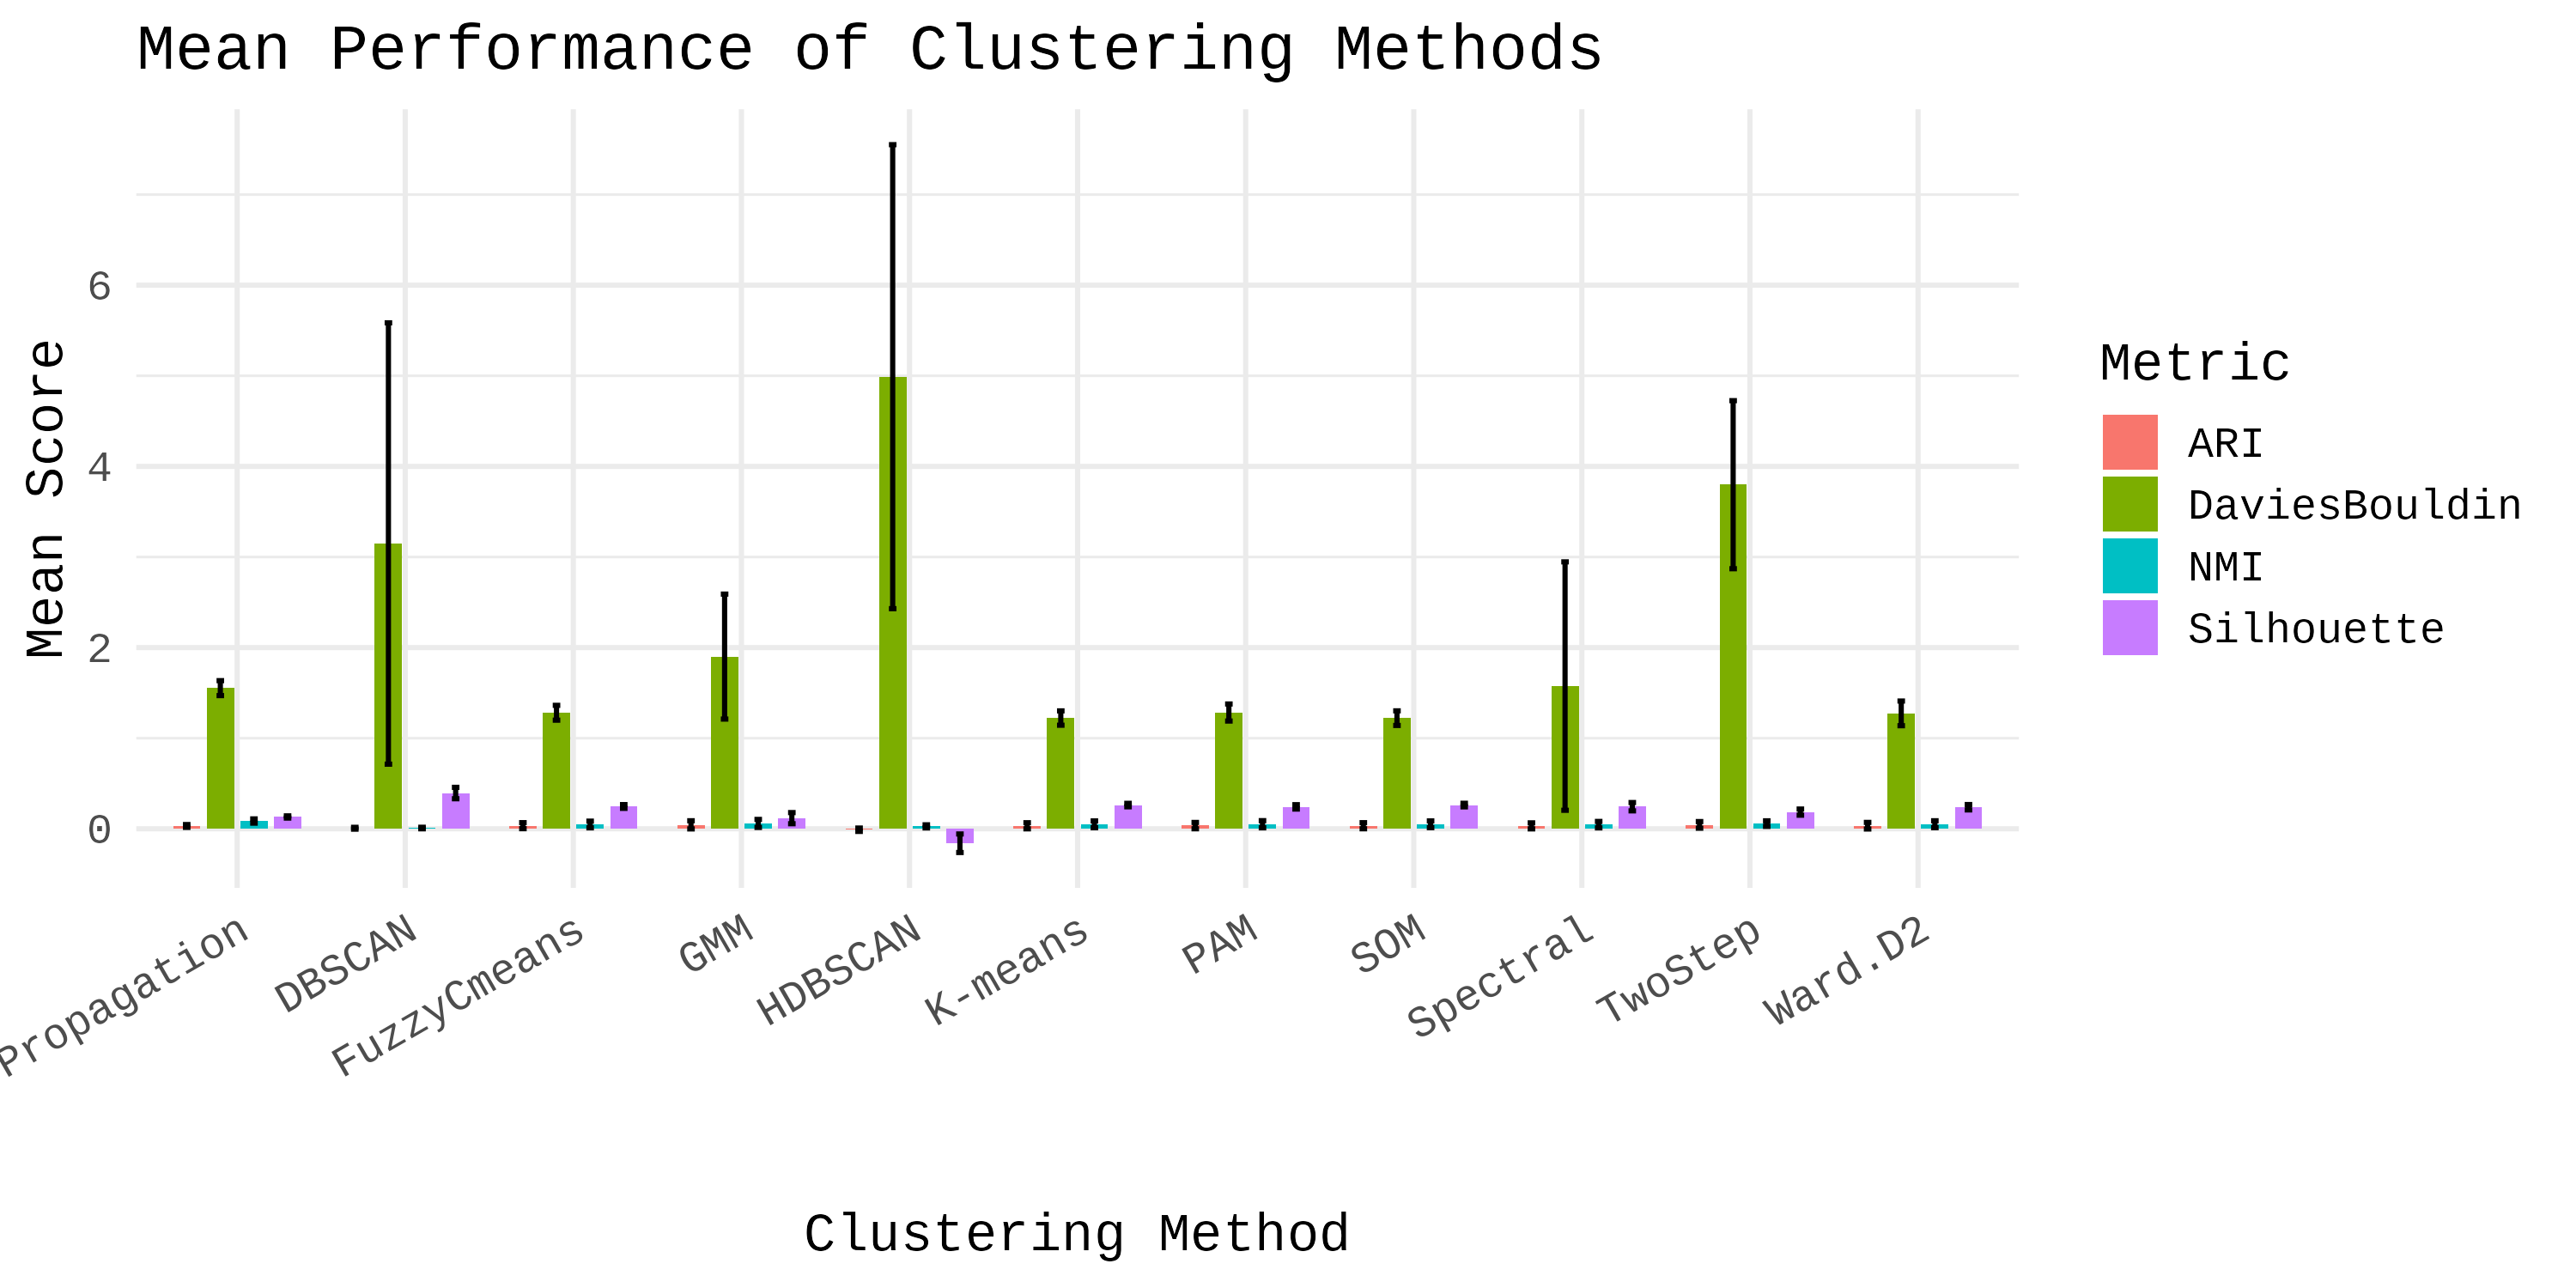

violin_scores_bounded.png


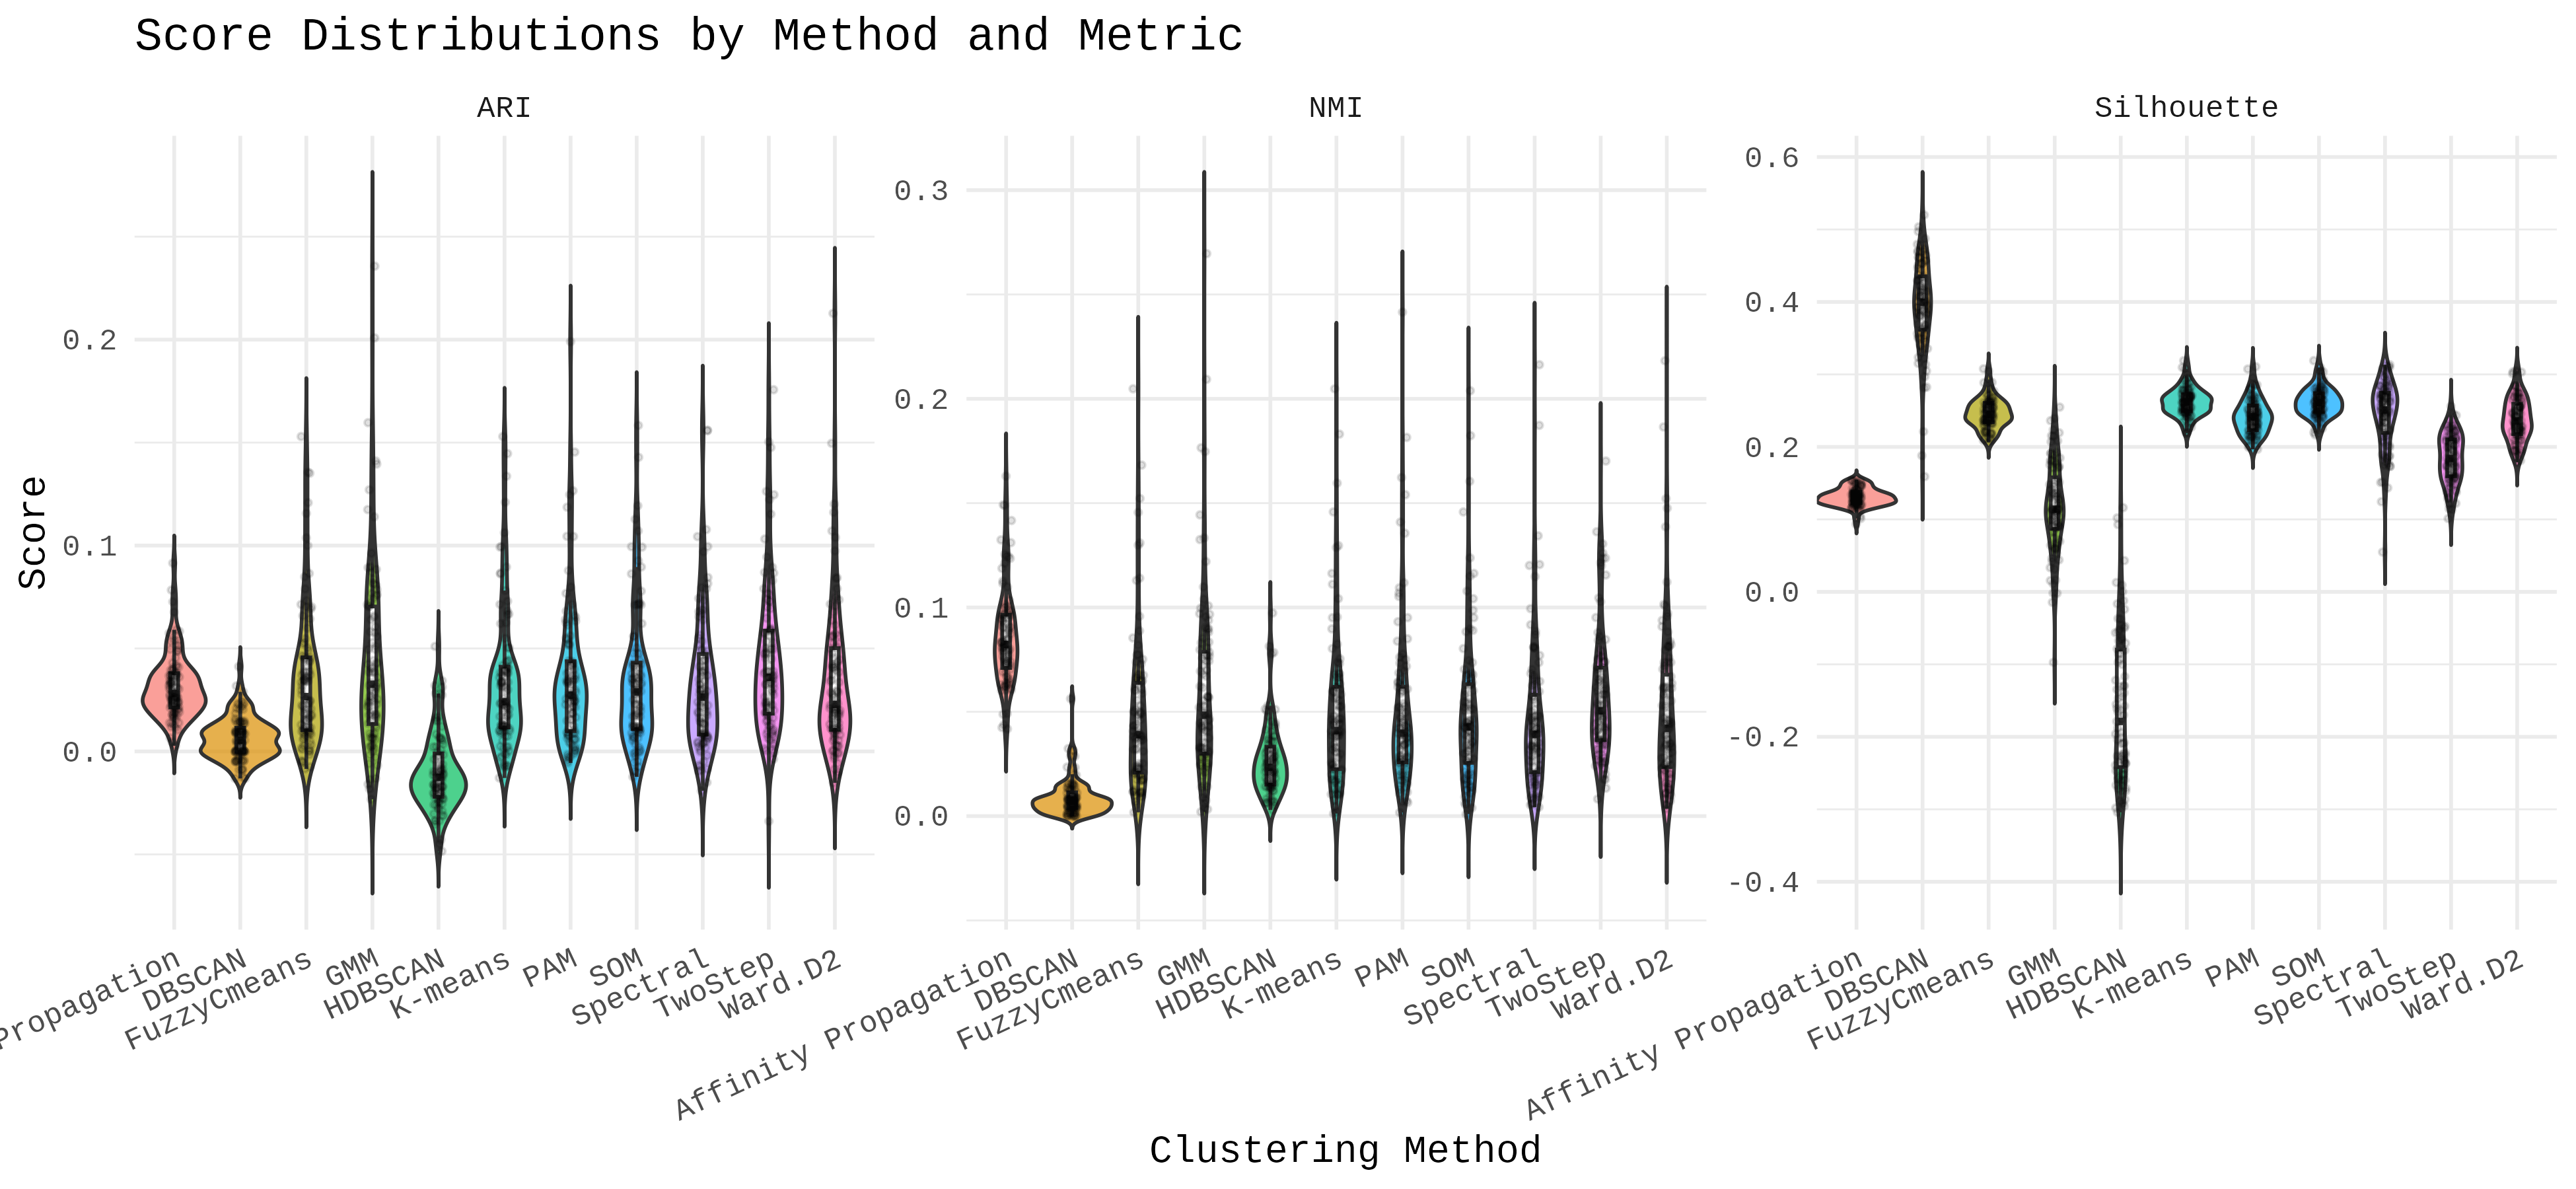

violin_daviesbouldin.png


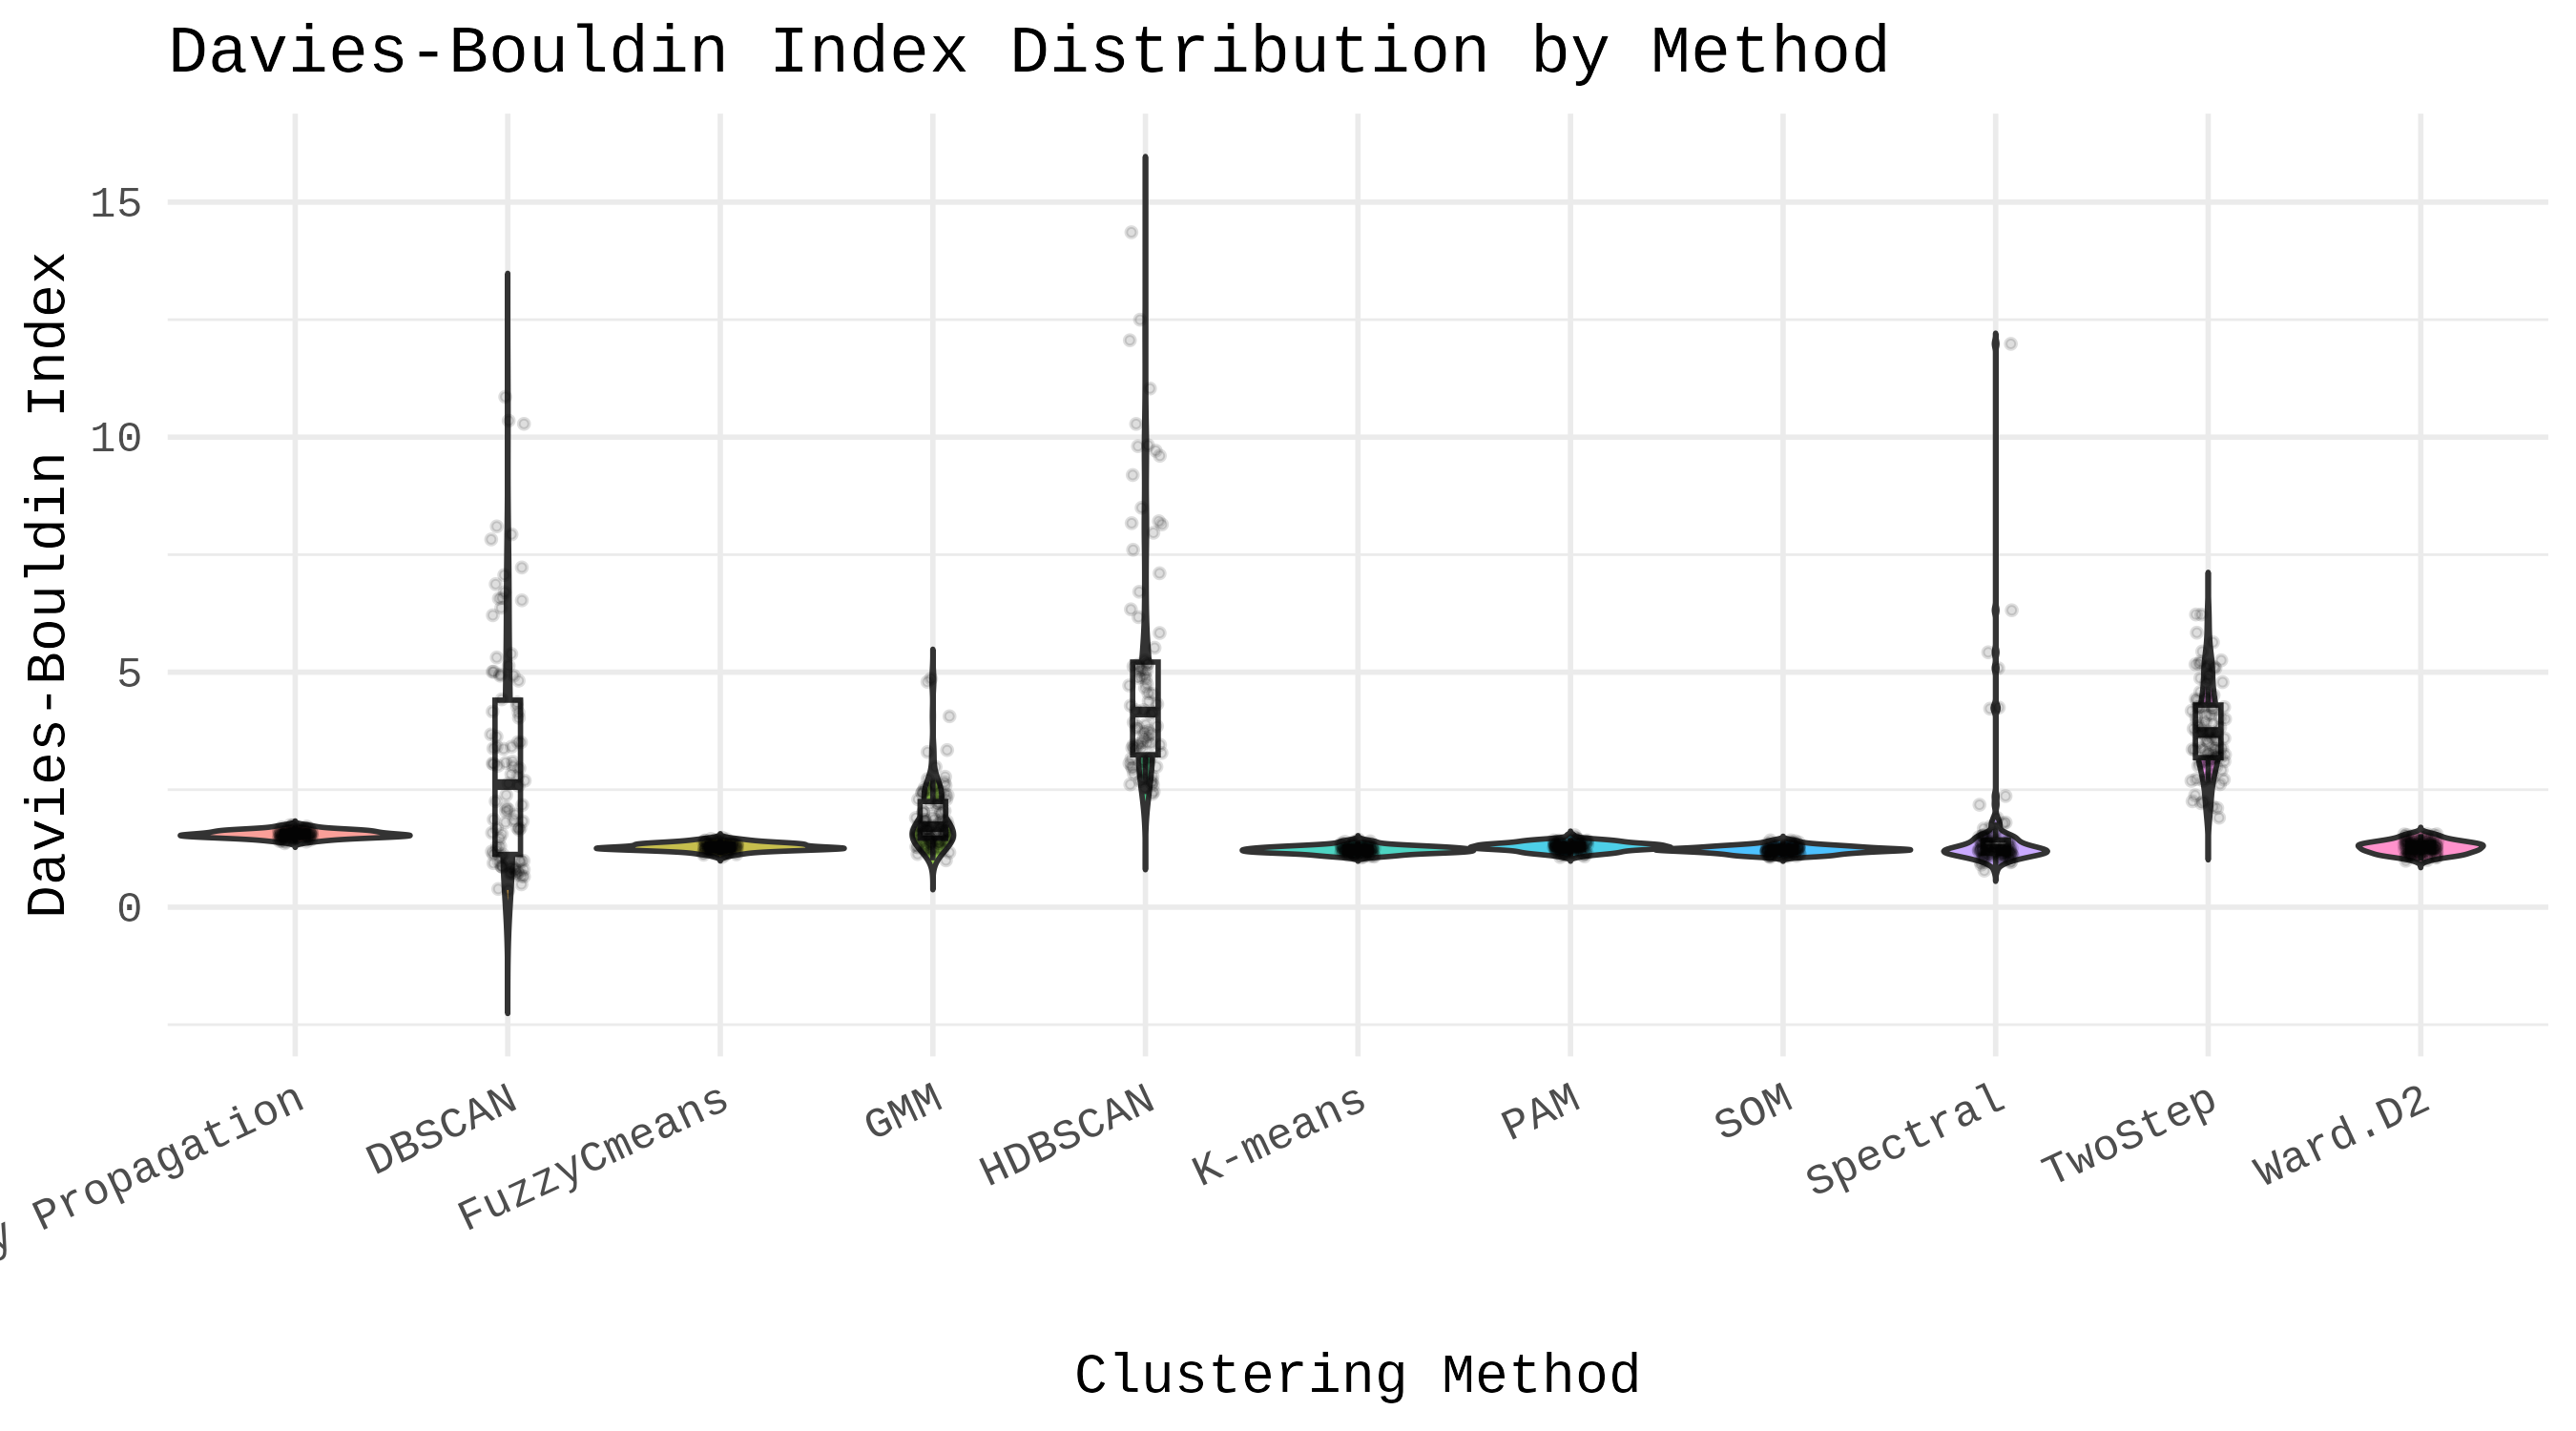

hist_fst.png


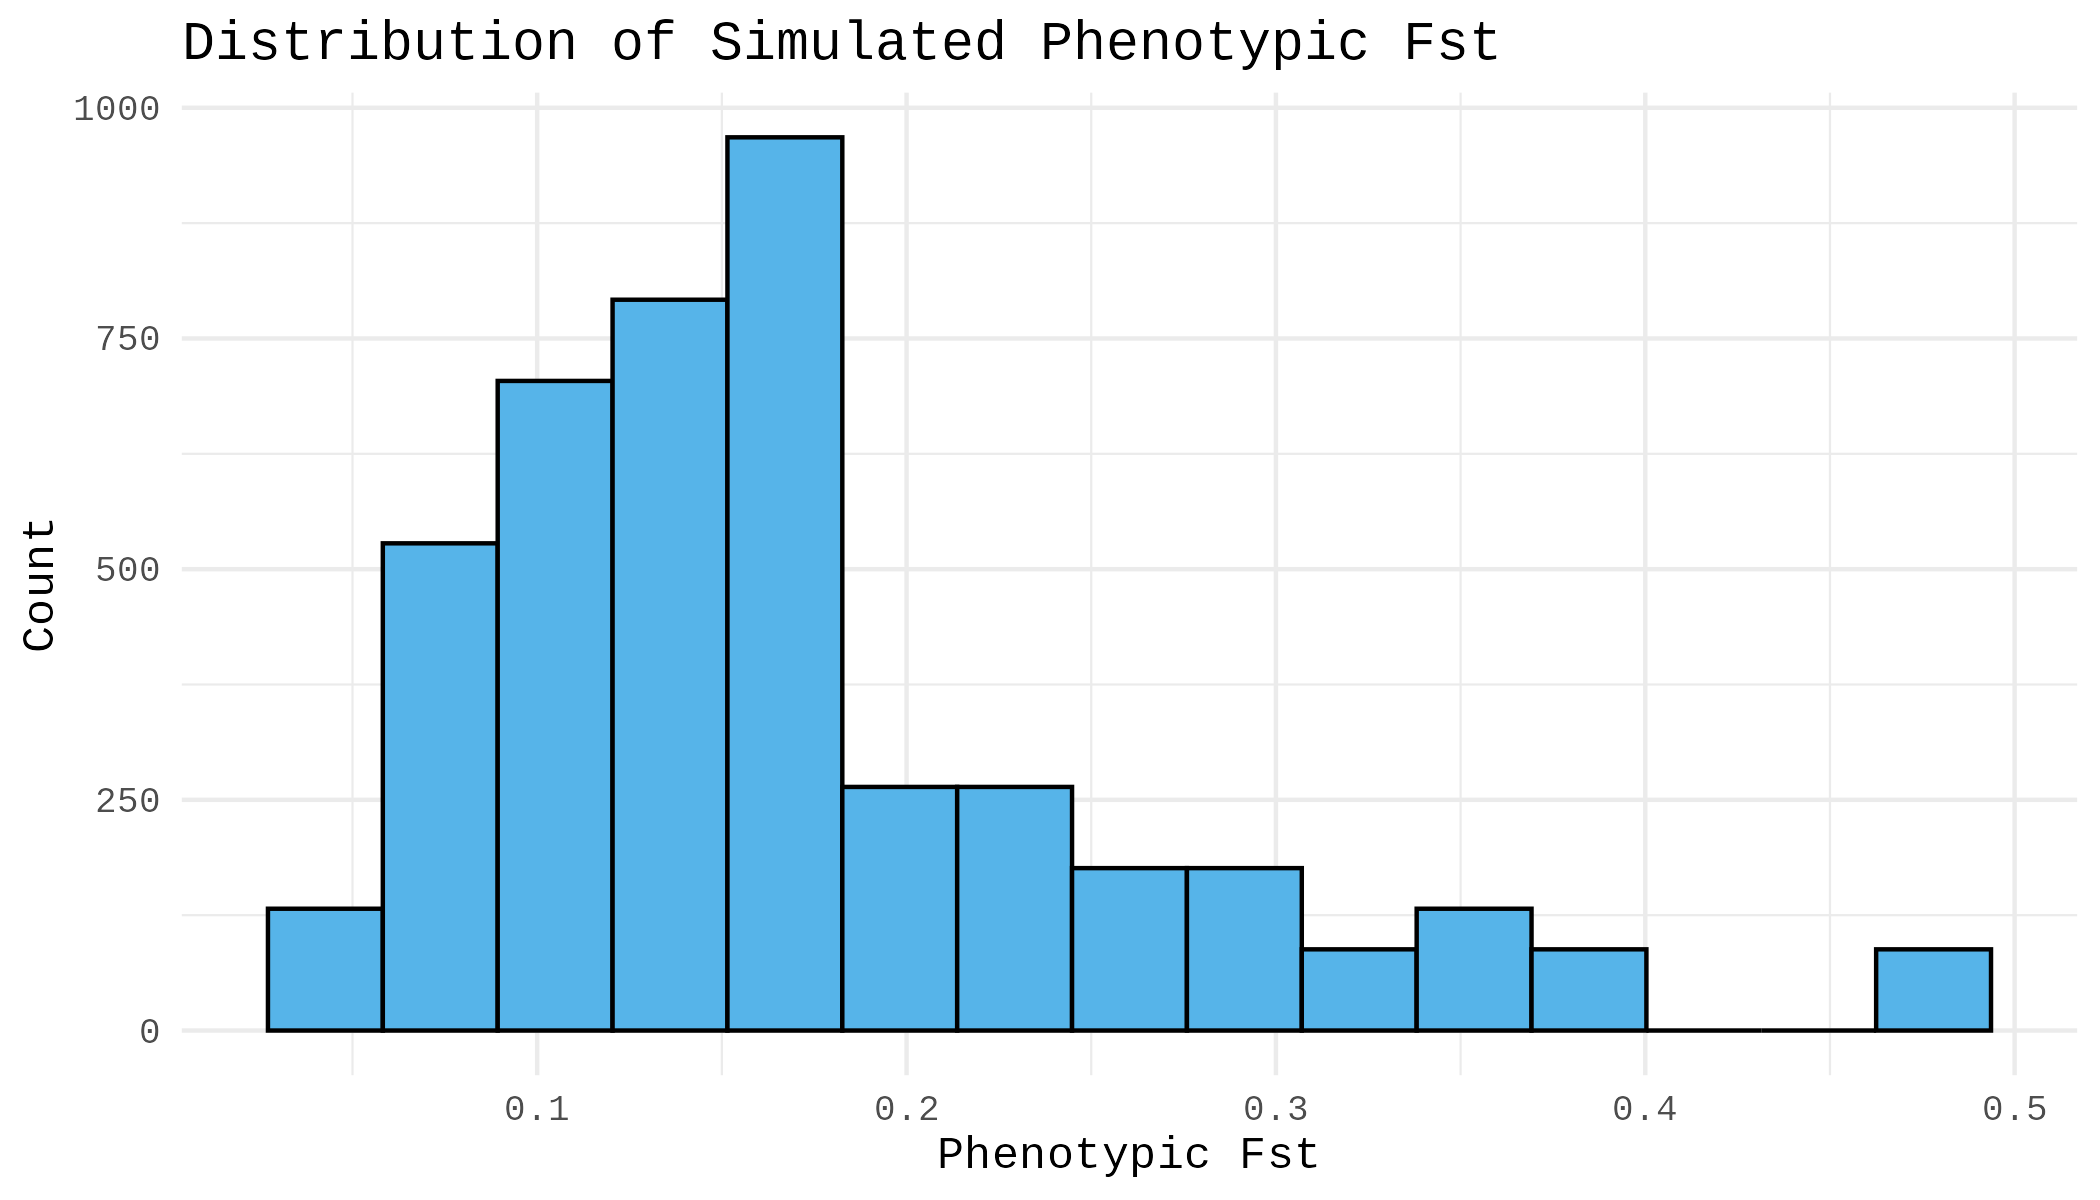

In [ ]:
from IPython.display import Image, display

for name in ["barplot_performance.png", "violin_scores_bounded.png",
             "violin_daviesbouldin.png", "hist_fst.png"]:
    print(name)
    display(Image(filename=f"/content/fonio_bench/results/realistic_100/{name}", width=900))

### 8. Interpretation and limitations

**What this reproduction shows:** with the author's own simulation and metric code, all 11 clustering algorithms recover the 3 planted fonio-calibrated populations near-randomly (ARI/NMI far below ideal levels, Davies–Bouldin large), matching the paper's conclusion that standard clustering assumptions (distinct, isotropic, homogeneous clusters) fail under realistic NUS trait structure (strong correlations, gamma-distributed yield, heteroscedasticity, Pst ≈ 0.15).

**Limitations (日本語含む):**
- The fonio empirical dataset of Bio et al. (2020) is **not** in the Zenodo archive; the calibration step is reproduced from the published trait statistics encoded in `params.R`, not from raw data. (日本語:Bio et al. (2020) のfonio実データはアーカイブに含まれず、`params.R` に記録された統計量から校正を再現しています。)
- No seed is specified in the archived material; we use `20250716 + rep`. Numerical values will differ slightly from the preprint figures while remaining near-random.
- The archived Fst-calibration check has the author-code quirk noted in section 4.
- The paper's idealized-scenario comparison and supplementary figures are outside this minimal scope. (日本語: 理想化シナリオとの比較は本ノートブックの範囲外です。)

**Provenance:** Zenodo record 15877863 (CC-BY-4.0), bioRxiv 2025.07.16.665063v1. Please cite the author if reusing any part of the code.